In [1]:
!pip install seaborn

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv('train.csv')

## How big is data?

In [4]:
df.shape

(891, 12)

## How does data look

In [5]:
df.head() # we use sample instead as sometimes data is like starting na rows nu aek jevy then alag aem vary kare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.sample(5) # 5 random rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
660,661,1,1,"Frauenthal, Dr. Henry William",male,50.0,2,0,PC 17611,133.6500,NaN,S
335,336,0,3,"Denkoff, Mr. Mitto",male,NaN,0,0,349225,7.8958,NaN,S
103,104,0,3,"Johansson, Mr. Gustaf Joel",male,33.0,0,0,7540,8.6542,NaN,S
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S
243,244,0,3,"Maenpaa, Mr. Matti Alexanteri",male,22.0,0,0,STON/O 2. 3101275,7.1250,NaN,S


## What is the data type of cols

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


int ma age can be converted after null values are removed as NAN cant be handelled in int

## Are there any missing values

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## How does the data look mathematically

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


insights are always on numerical data so if anomalies or null comes this helps

## Are there any duplicate value?

In [11]:
df.duplicated().sum()

np.int64(0)

ketla duplicate rows che ae keh and aene dro karay using pd.dropduplicates(pparams)

## Correlation between cols taki j output ne affect na kare ae cols ne we can remove

In [12]:
df.corr(numeric_only=True)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [13]:
df.corr(numeric_only=True)['Survived']  # as survived is output

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

## Questions ends------EDA(univariate) starts---

CategoricalData
1. Countplot

Survived
0    549
1    342
Name: count, dtype: int64

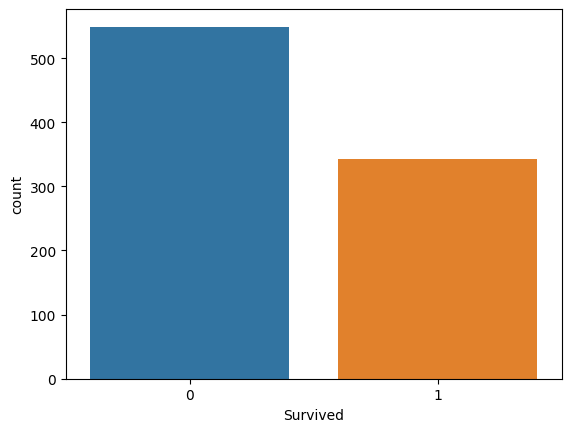

In [14]:
sns.countplot(x=df['Survived'].astype(str), hue=df['Survived'].astype(str))
df['Survived'].value_counts()

2. Piechart

<Axes: ylabel='count'>

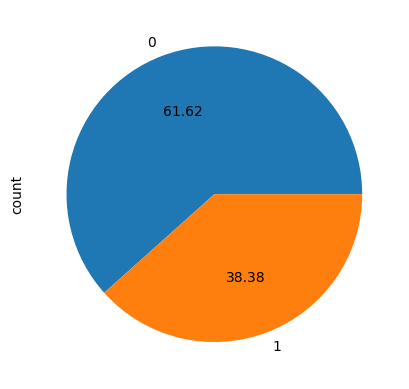

In [15]:
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: xlabel='Sex', ylabel='count'>

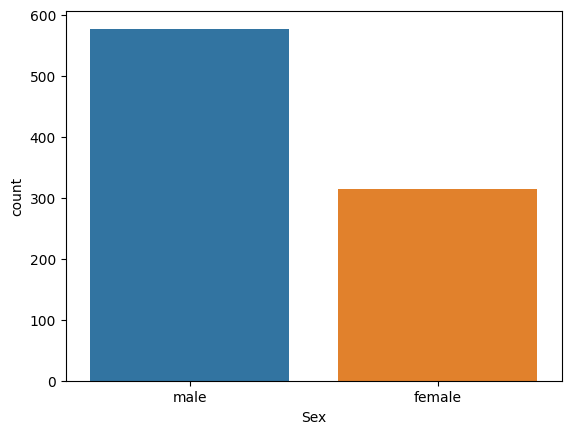

In [16]:
sns.countplot(x=df['Sex'],hue=df['Sex'])

<Axes: ylabel='count'>

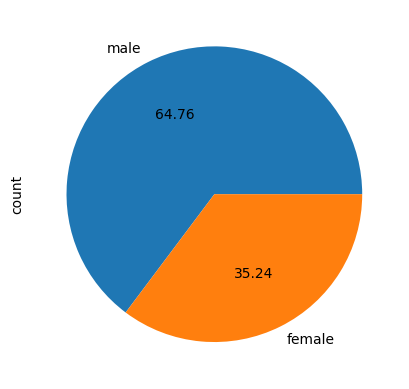

In [17]:
df['Sex'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: xlabel='Embarked', ylabel='count'>

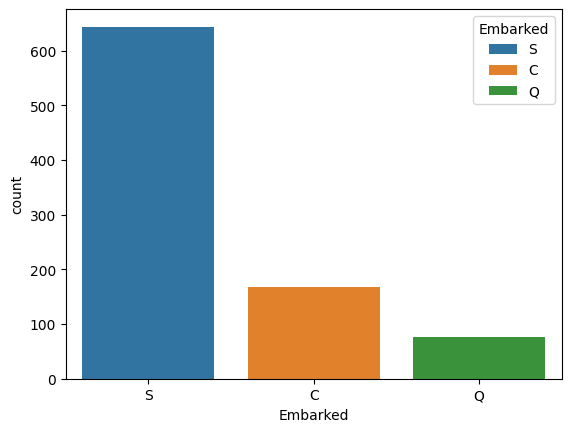

In [18]:
sns.countplot(x = df['Embarked'],hue=df['Embarked'])

## Numerical 

1. Histogram

In [19]:
!pip install matplotlib


In [20]:
import matplotlib.pyplot as plt

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

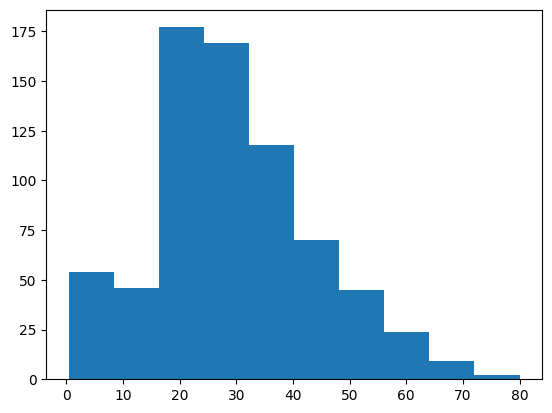

In [21]:
plt.hist(df['Age'])

2. Dist plot

C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_24068\3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

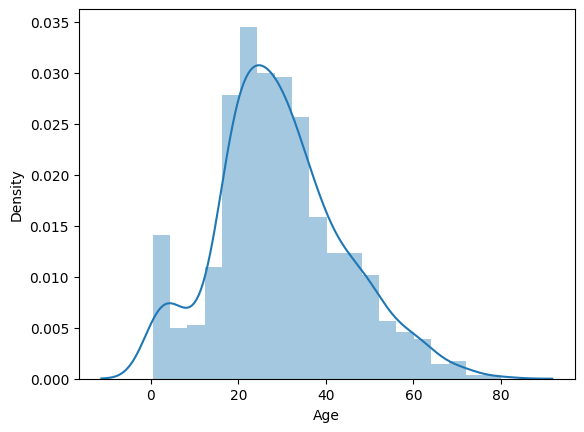

In [22]:
sns.distplot(df['Age'])

the line is pdf probability density function so koi random person aapde laiye to aeni age let say 40 thavani probability is 0.015

3. Boxplot

box nu mid id median

<Axes: xlabel='Fare'>

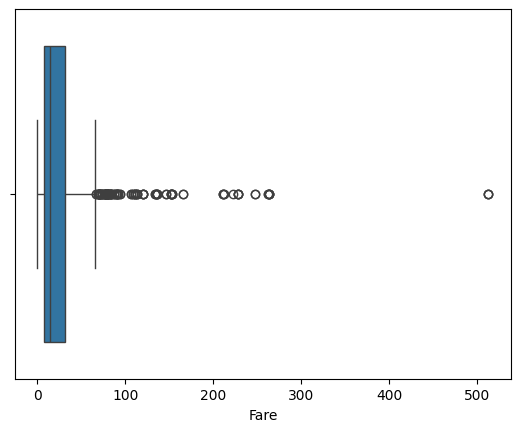

In [23]:
sns.boxplot(x=df['Fare'])

In [24]:
df['Age'].min()

np.float64(0.42)

In [25]:
df['Age'].skew()

np.float64(0.38910778230082704)

## Multivariate/bivariate

In [26]:
train = pd.read_csv('train.csv')
tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')
iris = sns.load_dataset('iris')

In [27]:
tips.shape


(244, 7)

In [28]:
train.shape


(891, 12)

In [29]:
flights.shape


(144, 3)

In [30]:
iris.shape

(150, 5)

In [31]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [32]:
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
203,16.40,2.50,Female,Yes,Thur,Lunch,2
201,12.74,2.01,Female,Yes,Thur,Lunch,2
125,29.80,4.20,Female,No,Thur,Lunch,6
41,17.46,2.54,Male,No,Sun,Dinner,2
153,24.55,2.00,Male,No,Sun,Dinner,4


In [33]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [34]:
tips.corr(numeric_only = True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


## Scatter--> Numerical-Numerical (Cols)

<Axes: xlabel='total_bill', ylabel='tip'>

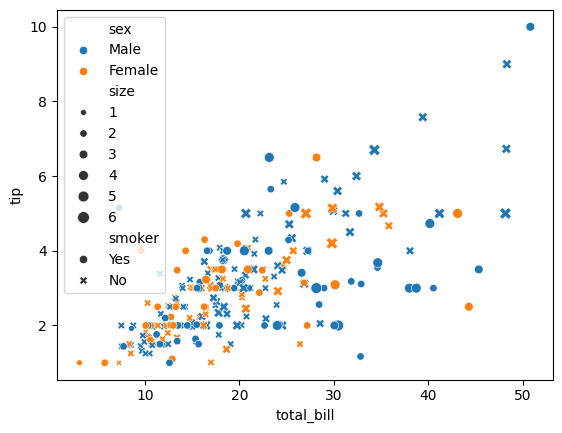

In [35]:
# multivariate 
sns.scatterplot(x = tips['total_bill'],y = tips['tip'],hue=tips['sex'],style=tips['smoker'],size=tips['size'])

## BarPlot,Boxplot,distplot --> Numerical-Categorical(cols)

In [36]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Age'>

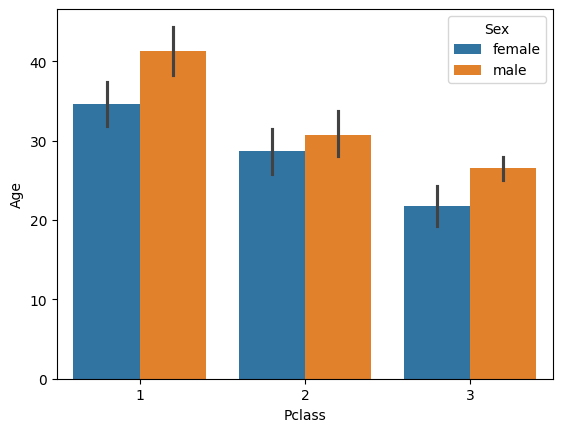

In [37]:
sns.barplot(x='Pclass', y='Age', hue='Sex', data=train)

BoxPlot

<Axes: xlabel='Pclass', ylabel='Age'>

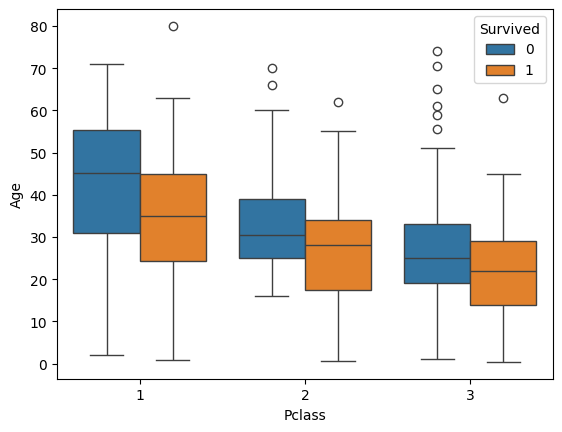

In [38]:
sns.boxplot(x=train['Pclass'],y=train['Age'],hue=train['Survived'])

DistPlot

C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_24068\1302179536.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[train['Survived']==0]['Age']) # multivalued joye che but hue ne badhudist ma na hoy
C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_24068\1302179536.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750

<Axes: xlabel='Age', ylabel='Density'>

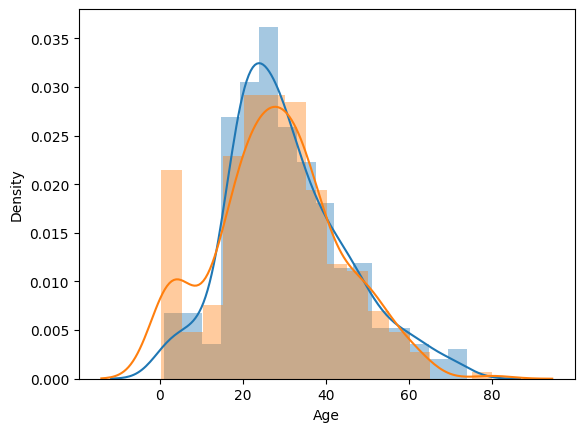

In [39]:
sns.distplot(train[train['Survived']==0]['Age']) # multivalued joye che but hue ne badhudist ma na hoy
sns.distplot(train[train['Survived']==1]['Age'])

C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_24068\4186967478.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train[train['Survived']==1]['Age'] ,hist=False)
C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_24068\4186967478.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

<Axes: xlabel='Age', ylabel='Density'>

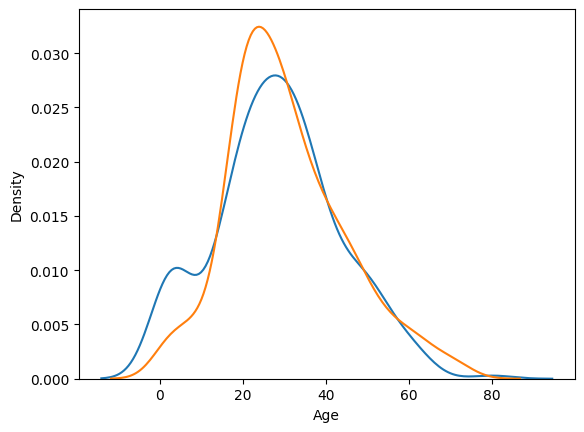

In [40]:
sns.distplot(train[train['Survived']==1]['Age'] ,hist=False)
sns.distplot(train[train['Survived']==0]['Age'],hist=False)

## Heatmap

<Axes: xlabel='Survived', ylabel='Pclass'>

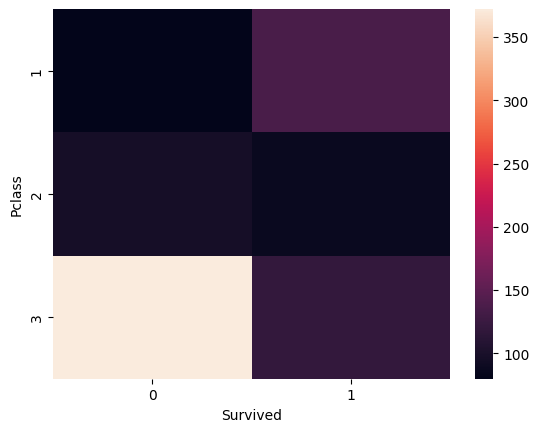

In [41]:
sns.heatmap(pd.crosstab(train['Pclass'],train['Survived'])) # % ketla survived as thats more beneficial as ahiya na khabar pade k ketla travel karta ta and aema thi ketla gya

<Axes: xlabel='Embarked'>

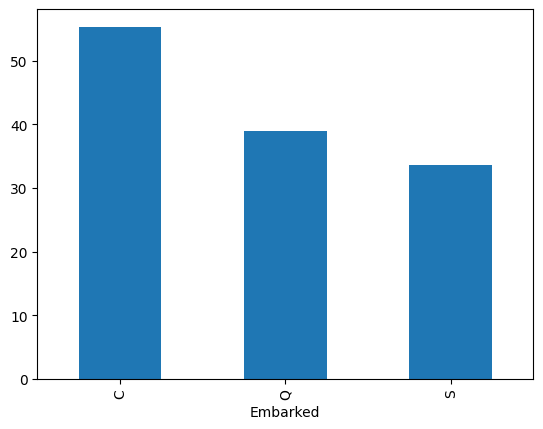

In [42]:
(train.groupby('Embarked').mean(numeric_only=True)['Survived']*100).plot(kind='bar')

Clustermap

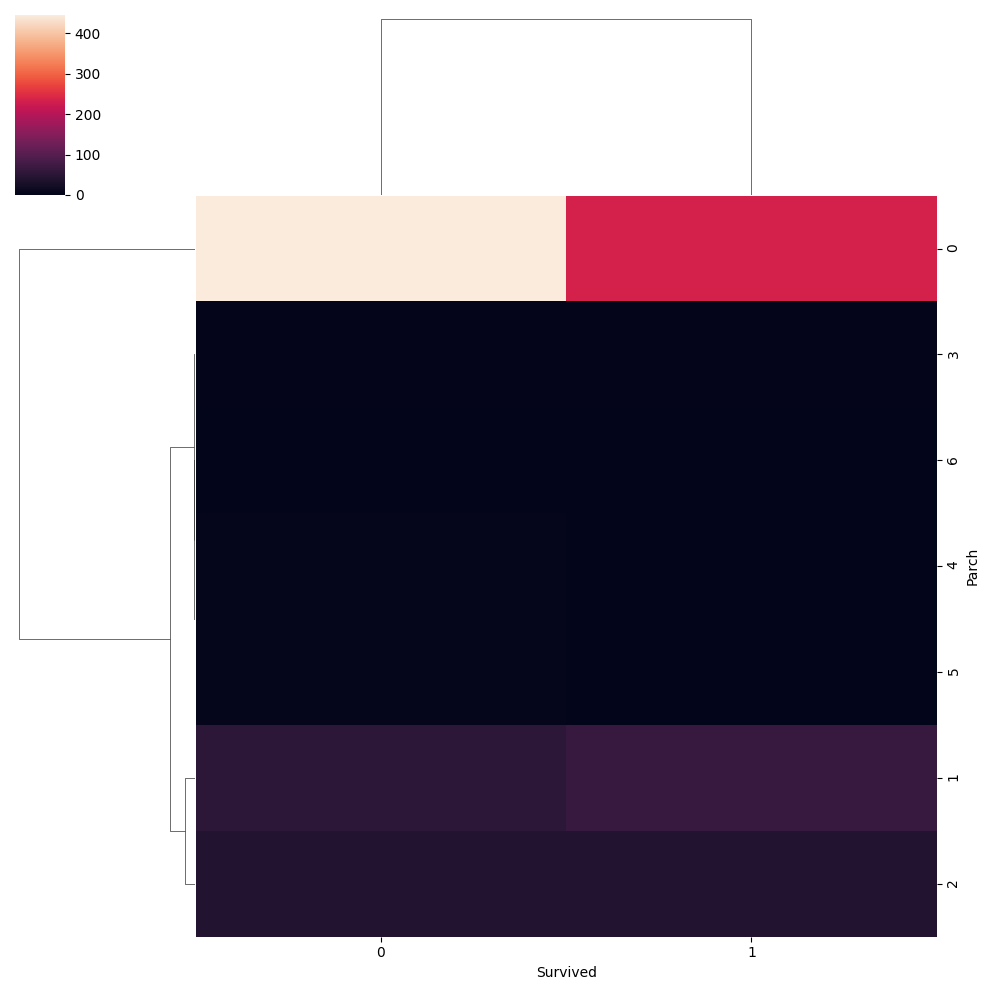

In [43]:
sns.clustermap(pd.crosstab(train['Parch'],train['Survived']))

## PairPlot,Lineplot-->Numerical-Numerical

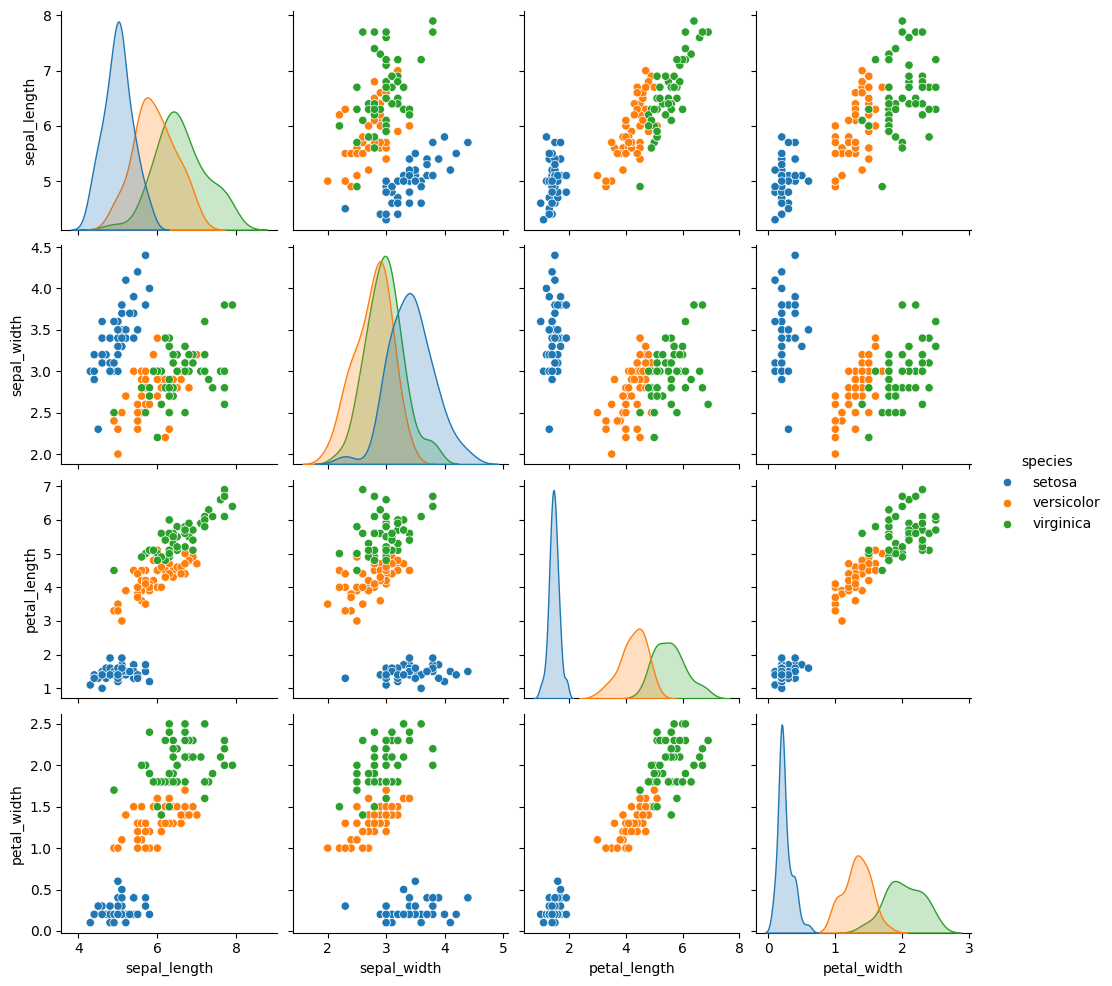

In [44]:
sns.pairplot(iris,hue='species')

linrplot--> time na unit k hoy aem

In [45]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [46]:
new = flights.groupby('year')['passengers'].sum()

<Axes: xlabel='year'>

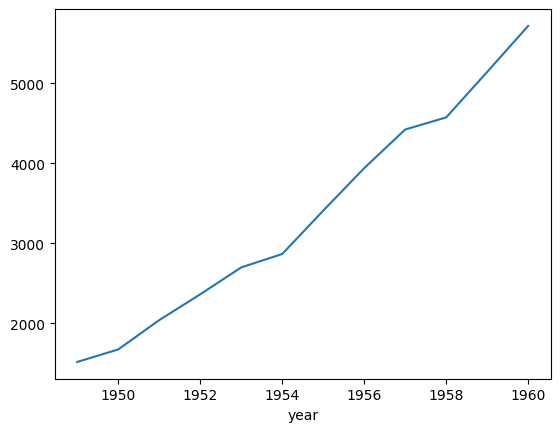

In [47]:
sns.lineplot(x=new.index, y=new.values)

C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_24068\2230379170.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))


<Axes: xlabel='year', ylabel='month'>

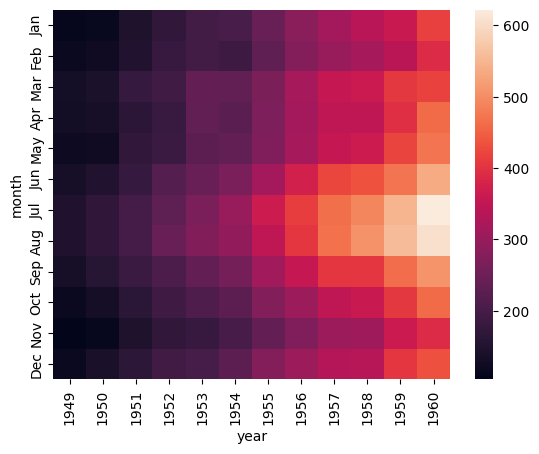

In [48]:
sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))

## Shortcut

In [51]:
!pip install "setuptools<82.0.0"

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ----------------------------- ---------- 0.8/1.1 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 2.4 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 83.0.0
    Uninstalling setuptools-83.0.0:
      Successfully uninstalled setuptools-83.0.0


In [54]:
from data_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 385.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]